# Robust Empirical Mode Decomposition (REMD)

**REMD** (Peng *et al.*, 2019; also called EMD-SSSC) keeps the classical EMD
sifting loop — cubic-spline envelopes and a local mean — but replaces Huang's
fixed **hard** sifting-stopping threshold with a **Soft Sifting Stopping
Criterion (SSSC)**.  The SSSC monitors an objective function of the local mean
and then **looks back** to the locally optimal iteration, which suppresses both
*undersifting* and *oversifting* without a user-chosen SD / Cauchy cutoff.

The envelope stage itself is also regularized by **mirror-extending extrema**
(Rilling / Flandrin) before spline interpolation, which reduces end effects.

**References**

> D. Peng, Z. Liu, Y. Jin, Y. Qin.  
> *Improved EMD with a Soft Sifting Stopping Criterion and Its Application to
Fault Diagnosis of Rotating Machinery.* Journal of Mechanical Engineering,
55(10):122–132, 2019.  https://doi.org/10.3901/JME.2019.10.122

> Z. Liu, D. Peng, M. J. Zuo, J. Xia, Y. Qin.  
> *Improved Hilbert–Huang transform with soft sifting stopping criterion and its
application to fault diagnosis of wheelset bearings.*
ISA Transactions, 125:426–444, 2022.  https://doi.org/10.1016/j.isatra.2021.07.011

This notebook uses `pysdkit.REMD` (faithful port of MATLAB `emd_sssc.m`).
Section 2 derives the SSSC from the papers; later cells reproduce the File
Exchange AM–FM demo and compare the first IMF against classical EMD.


## 1. Imports

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "pysdkit").is_dir():
    for parent in ROOT.parents:
        if (parent / "pysdkit").is_dir():
            ROOT = parent
            break
if str(ROOT) not in sys.path and (ROOT / "pysdkit").is_dir():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from pysdkit import REMD, EMD
from pysdkit.plot import plot_IMFs, plot_IMFs_amplitude_spectra

print(REMD())

Robust Empirical Mode Decomposition (REMD)


## 2. Algorithm principles

Classical EMD (Huang *et al.*, 1998) writes a real signal as a finite stack of
intrinsic mode functions (IMFs) plus a residual,

$$
x(t)=\sum_{i=1}^{N} c_i(t)+r_N(t).
$$

Each $c_i$ is obtained by **sifting**: from the current residual $h_{i0}=r_{i-1}$
(with $r_0=x$), form upper / lower cubic-spline envelopes $u_k$, $l_k$, take the
local mean

$$
m_{ik}(t)=\frac{u_k(t)+l_k(t)}{2},
\qquad
h_{ik}(t)=h_{i,k-1}(t)-m_{ik}(t),
$$

and stop when $h_{ik}$ is judged to be an IMF.  REMD **does not change** this
mean-subtraction geometry.  What it changes is *when* to stop and *which*
iteration to keep.

### 2.1 Hard stopping in plain EMD

Huang’s original numerical criterion is a Cauchy-type **standard deviation**
between consecutive sifts,

$$
\mathrm{SD}_k
=\sum_{t}
\frac{\bigl|h_{k-1}(t)-h_k(t)\bigr|^2}{h_{k-1}(t)^2},
$$

and sifting stops once $\mathrm{SD}_k$ falls below a preset threshold
(typically $0.2$–$0.3$).  Rilling’s three-threshold rule and Wu’s “always sift
10 times” are the same idea: a **hard sifting stopping criterion (H-SSC)** that
needs a threshold chosen a priori.

Peng *et al.* show that this is not adaptive:

| Failure mode | Too few sifts | Too many sifts |
|---|---|---|
| Name in the paper | **undersifting** (欠筛) | **oversifting** (过筛) |
| Effect | several true tones packed into one IMF | one true tone split across several IMFs |
| Both are | **mode mixing** | **mode mixing** |

On a two-component FM test signal, a single sift mixed $200\,\mathrm{Hz}$ and
$600\,\mathrm{Hz}$ bands into IMF1, while 200 sifts split the lower FM across
IMF2 and IMF3.  Either way the Hilbert spectrum becomes untrustworthy.

A second classical IMF condition,

$$
\lim_{k\to\infty} m_{ik}[n]=0
\quad\text{for all samples }n,
$$

is an *ideal* statement: the local mean should vanish **uniformly**.  A scalar
SD on $\|h_k-h_{k-1}\|$ does not guarantee that.

### 2.2 Soft objective on the local mean

SSSC therefore scores the **local mean** $m_{ik}$ itself, not the increment of
$h$.  Two complementary descriptors are used (Peng *et al.*, eqs. 3–5).

**Global energy** — root-mean-square: if $m_{ik}\to 0$ uniformly then RMS
$\to 0$,

$$
\mathrm{RMS}(m_{ik})
=\sqrt{\frac{1}{N_s}\sum_{n=1}^{N_s} m_{ik}[n]^2}.
$$

**Local impulsiveness** — excess kurtosis (Gaussian $\mapsto 0$): if a few
samples of $m_{ik}$ remain as large spikes while most of the trace is already
tiny, RMS can look small while the mean is *not* uniformly near zero,

$$
\mathrm{EK}(m_{ik})
=\frac
{\displaystyle\frac{1}{N_s}\sum_{n}\bigl(m_{ik}[n]-\bar m_{ik}\bigr)^4}
{\displaystyle\Bigl(\frac{1}{N_s}\sum_{n}\bigl(m_{ik}[n]-\bar m_{ik}\bigr)^2\Bigr)^2}
-3.
$$

RMS alone misses spike-like residuals; EK alone misses a large but
almost-constant offset.  The paper’s objective is their sum

$$
f_{ik}
=\mathrm{RMS}(m_{ik})+\bigl|\mathrm{EK}(m_{ik})\bigr|.
$$

MATLAB `emd_sssc` (`ssc='liu'`) implements the same quantity as

$$
f(j)=\mathrm{RMS}(m_j)+\bigl|\mathrm{Kurt}(m_j)-3\bigr|,
$$

i.e. Pearson kurtosis (normal $\to 3$), which is identical to $|\mathrm{EK}|$.

### 2.3 Heuristic: when to stop, which iterate to keep

Unlike H-SSC, **no threshold is placed on $f$**.  For IMF $i$ the inner loop
records $f_{i1},f_{i2},\ldots$ and stops at iteration $k$ only when **both**
hold (Peng *et al.*, Fig. 4; MATLAB `is_sifting_process_stop`):

1. Huang’s first IMF condition: extrema and zero-crossings nearly match,
   $|N_z-N_e|<2$;
2. three consecutive objective values are non-decreasing,
   $f_{i,k-2}\le f_{i,k-1}\le f_{i,k}$ (with $k\ge 3$).

Condition 2 is the *soft* part: $f$ has started to rise, so further sifting
is no longer improving the mean.  The IMF is **not** the last iterate.  After
stopping, REMD looks back to the locally optimal sifting count

$$
k^\star=\arg\min_{1\le j\le k} f_{ij}
$$

and sets $c_i\leftarrow h_{i,k^\star}$.  That is MATLAB’s “critical step”
`[~,opt0]=min(fvs(i,1:j))`.  If $k$ hits `max_iter` first, the same minimizer
is still used on the recorded prefix.

Outer loop: $r_i=r_{i-1}-c_i$, and EMD stops when the residual has fewer than
three extrema or its energy ratio drops below $0.001$.

### 2.4 Mirror extension (end effects)

Before each spline envelope, extrema are **mirror-extended** by a fraction
`ext_ratio` of the original length (default $0.2$; set $0$ to disable).  This
is the Rilling / Flandrin construction used by Peng *et al.* and by
`emd_sssc.m`.  Classical Huang EMD often uses characteristic waves at the
ends, which is a common source of end-effect leakage into early IMFs.

### 2.5 What improves relative to EMD

| | Classical EMD | REMD / EMD-SSSC |
|---|---|---|
| Local mean | average of cubic-spline envelopes | **same** |
| Stop rule | hard SD / 3-threshold / fixed $K$ | SSSC on $f(m)$ + IMF extrema test |
| Iterate kept | the last one | $\arg\min_j f(j)$ |
| Threshold | must be chosen | **none** on $f$ |
| Ends | often characteristic waves | mirror extension (`ext_ratio`) |
| Typical failure | undersift / oversift $\to$ mode mixing | locally optimal $k^\star$ |

Empirically (Peng *et al.*, Tables 1–3 vs Rilling and Wu; Liu *et al.*, 2022),
REMD yields smaller RMSE on known AM–FM components, a lower index of
orthogonality

$$
\mathrm{IO}
=\sum_{i\neq j}
\frac{\bigl|\langle c_i,c_j\rangle\bigr|}{\|x\|^2},
$$

fewer spurious IMFs, and fewer sifts — which also limits error accumulation
in the spline loop.  Completeness is unchanged: IMFs plus residual still
reconstruct $x$.

`pysdkit.REMD(..., return_all=True)` returns `(imf, ort, fvs, iter_num)` so
that $f_{ij}$ and $k^\star$ can be plotted (Section 7).

## 3. MATLAB / paper demo signal

The File Exchange header example (and typical REMD paper demos) use an AM-FM
chirp plus a low-frequency tone:

$$
x(t) = \big(2 + \cos(2\pi\,0.5\,t)\big)\,
\cos\big(2\pi\,5\,t + 15\,t^2\big)
+ \cos(2\pi\,2\,t).
$$

Sampling rate $f_s = 10\,\mathrm{kHz}$. Full MATLAB length is $N=30000$; here we
use a slightly shorter segment for a quicker notebook while keeping the same
structure.


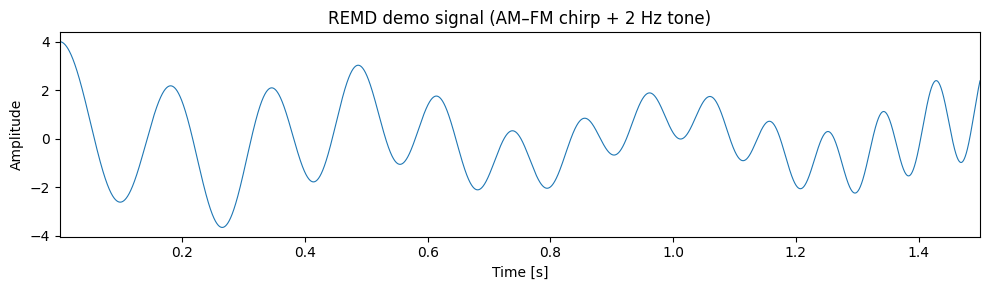

In [2]:
fs = 10000.0
N = 15000
t = np.arange(1, N + 1, dtype=float) / fs

x = (2.0 + np.cos(2.0 * np.pi * 0.5 * t)) * np.cos(
    2.0 * np.pi * 5.0 * t + 15.0 * t**2
) + np.cos(2.0 * np.pi * 2.0 * t)

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(t, x, lw=0.8)
ax.set_xlabel("Time [s]")
ax.set_ylabel("Amplitude")
ax.set_title("REMD demo signal (AM–FM chirp + 2 Hz tone)")
ax.set_xlim(t[0], t[-1])
fig.tight_layout()
plt.show()

## 4. Decompose with REMD

`max_imfs` is the maximum number of IMFs **excluding** the residual (same as
MATLAB). Soft stopping uses `ssc='liu'` and mirror ratio `ext_ratio=0.2`.


In [3]:
decomp = REMD(max_imfs=6, max_iter=30, ext_ratio=0.2, ssc="liu")
imfs, ort, fvs, iter_num = decomp(x, return_all=True)

print(f"IMF matrix shape (IMFs + residual): {imfs.shape}")
print(f"Index of orthogonality: {ort:.6e}")
print(f"Selected sifting iterations: {iter_num.astype(int)}")
print(
    f"Reconstruction rel. error: {np.linalg.norm(imfs.sum(0) - x) / np.linalg.norm(x):.3e}"
)

IMF matrix shape (IMFs + residual): (5, 15000)
Index of orthogonality: 8.943933e-03
Selected sifting iterations: [1 1 4 1]
Reconstruction rel. error: 9.625e-17


## 5. IMF visualization (paper-style stack)


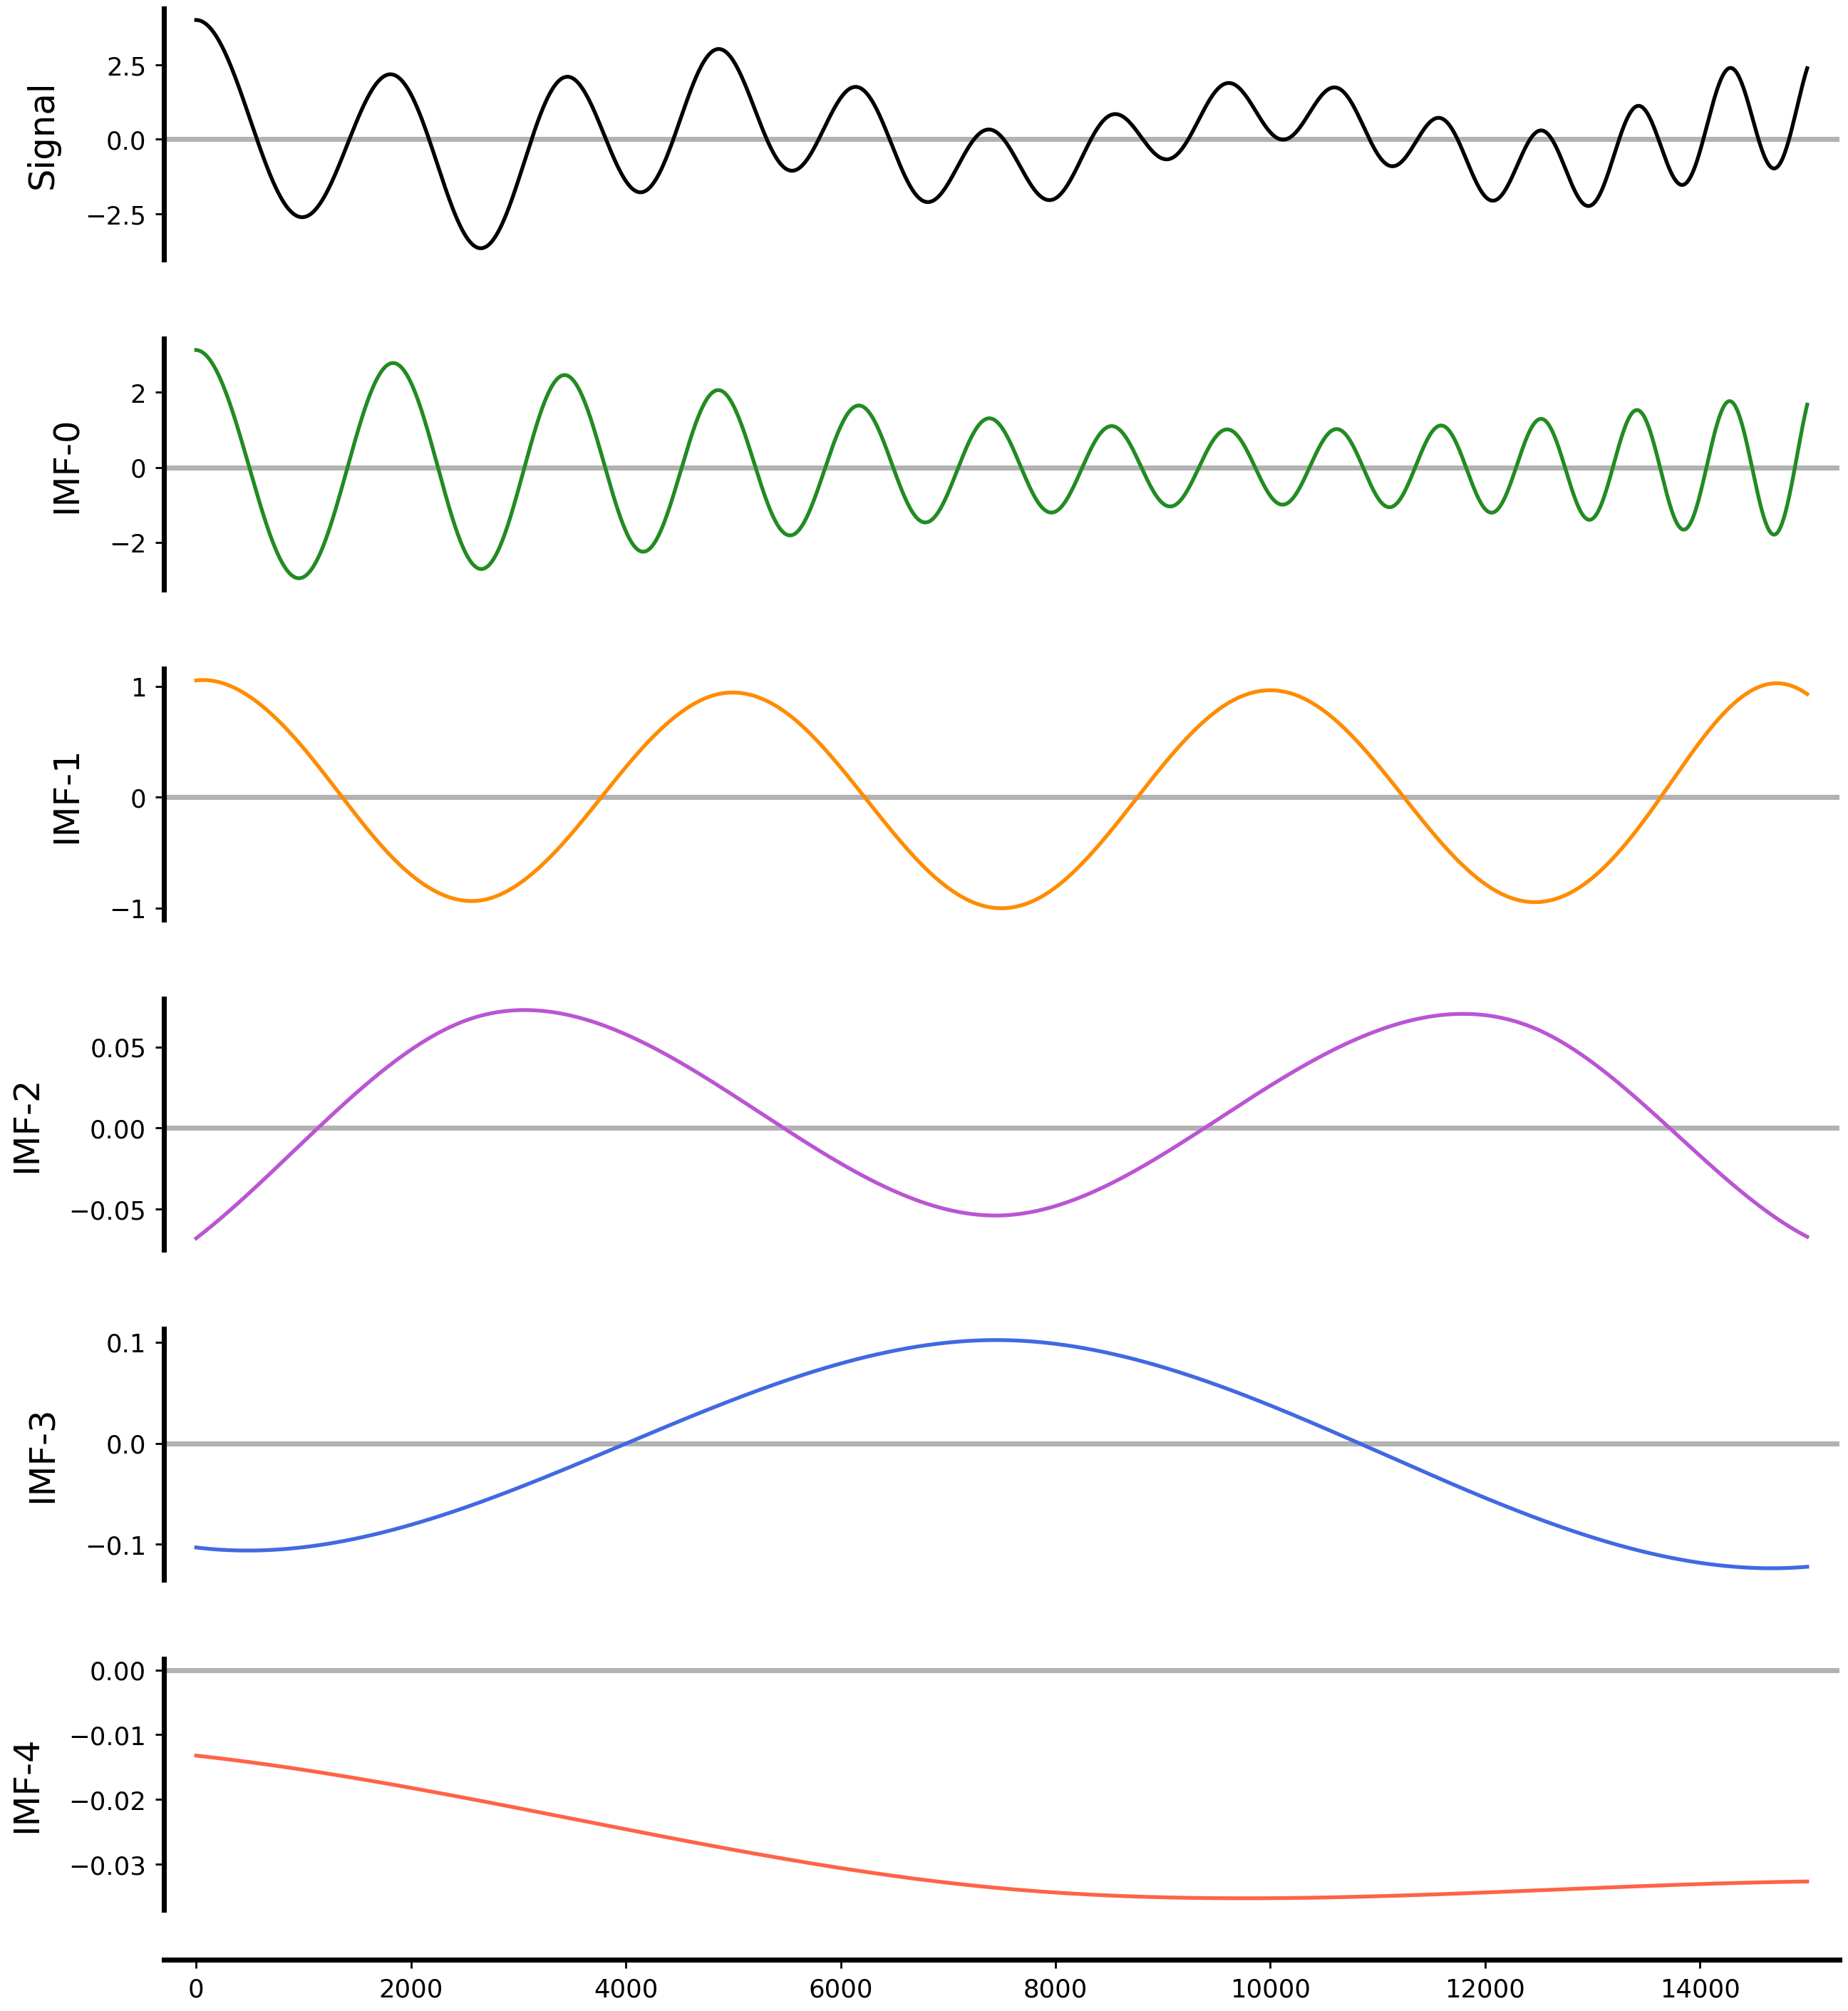

In [4]:
plot_IMFs(x, imfs, fs=fs)
plt.show()

## 6. Amplitude spectra

The tone near $2\,\mathrm{Hz}$ and the chirp energy should separate across
early IMFs / residual, consistent with REMD paper figures.


run classic


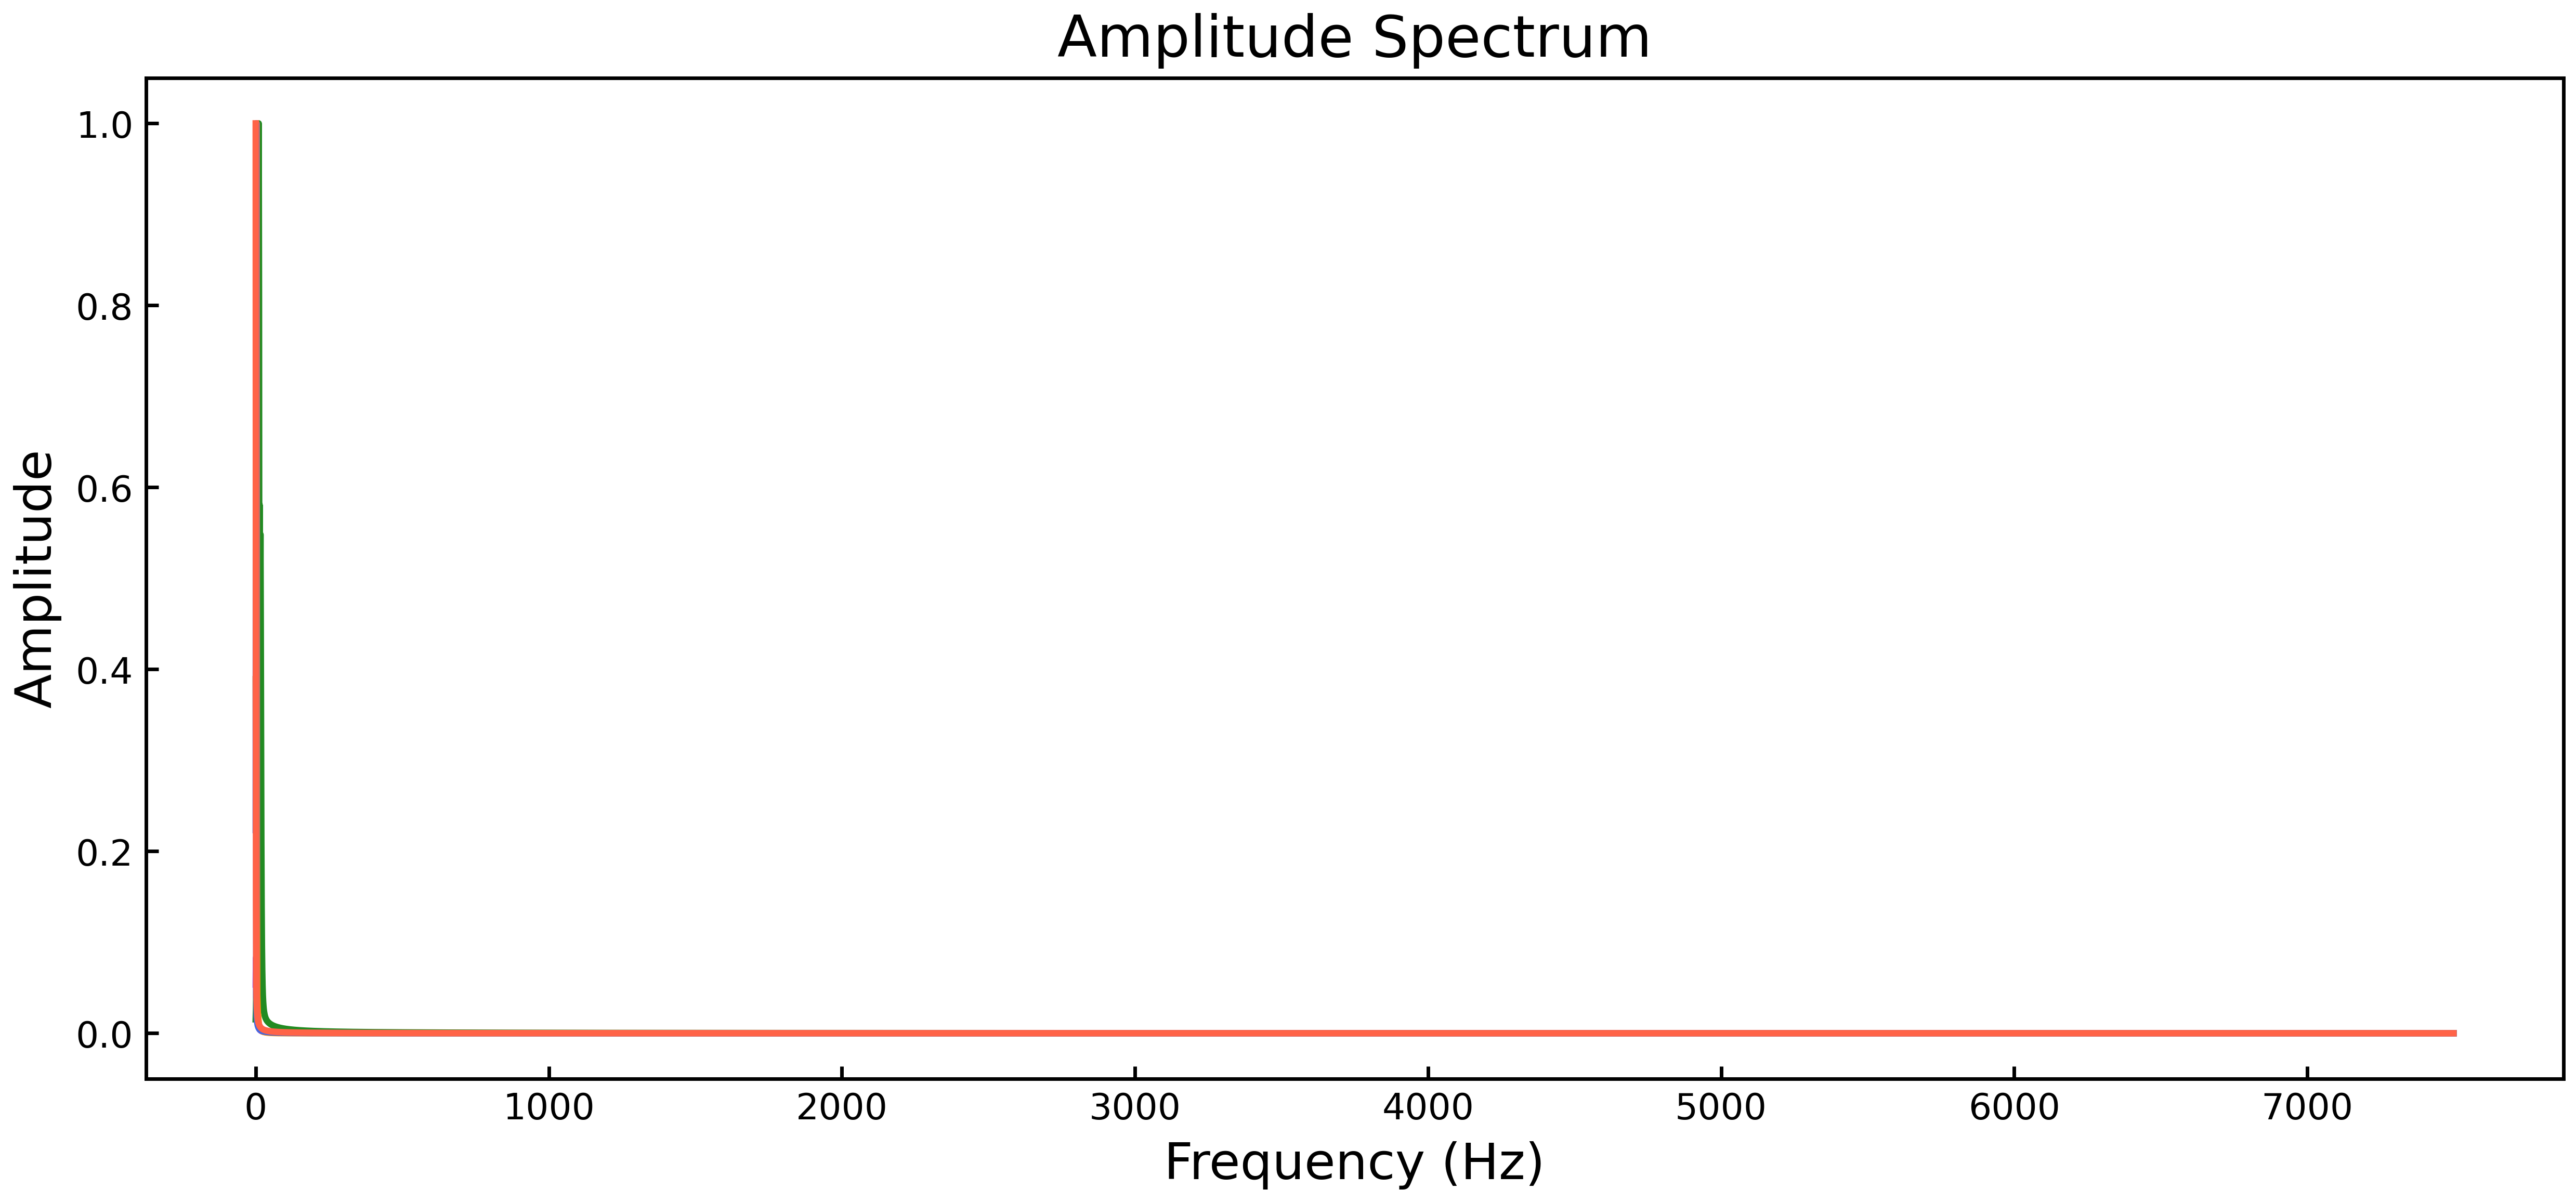

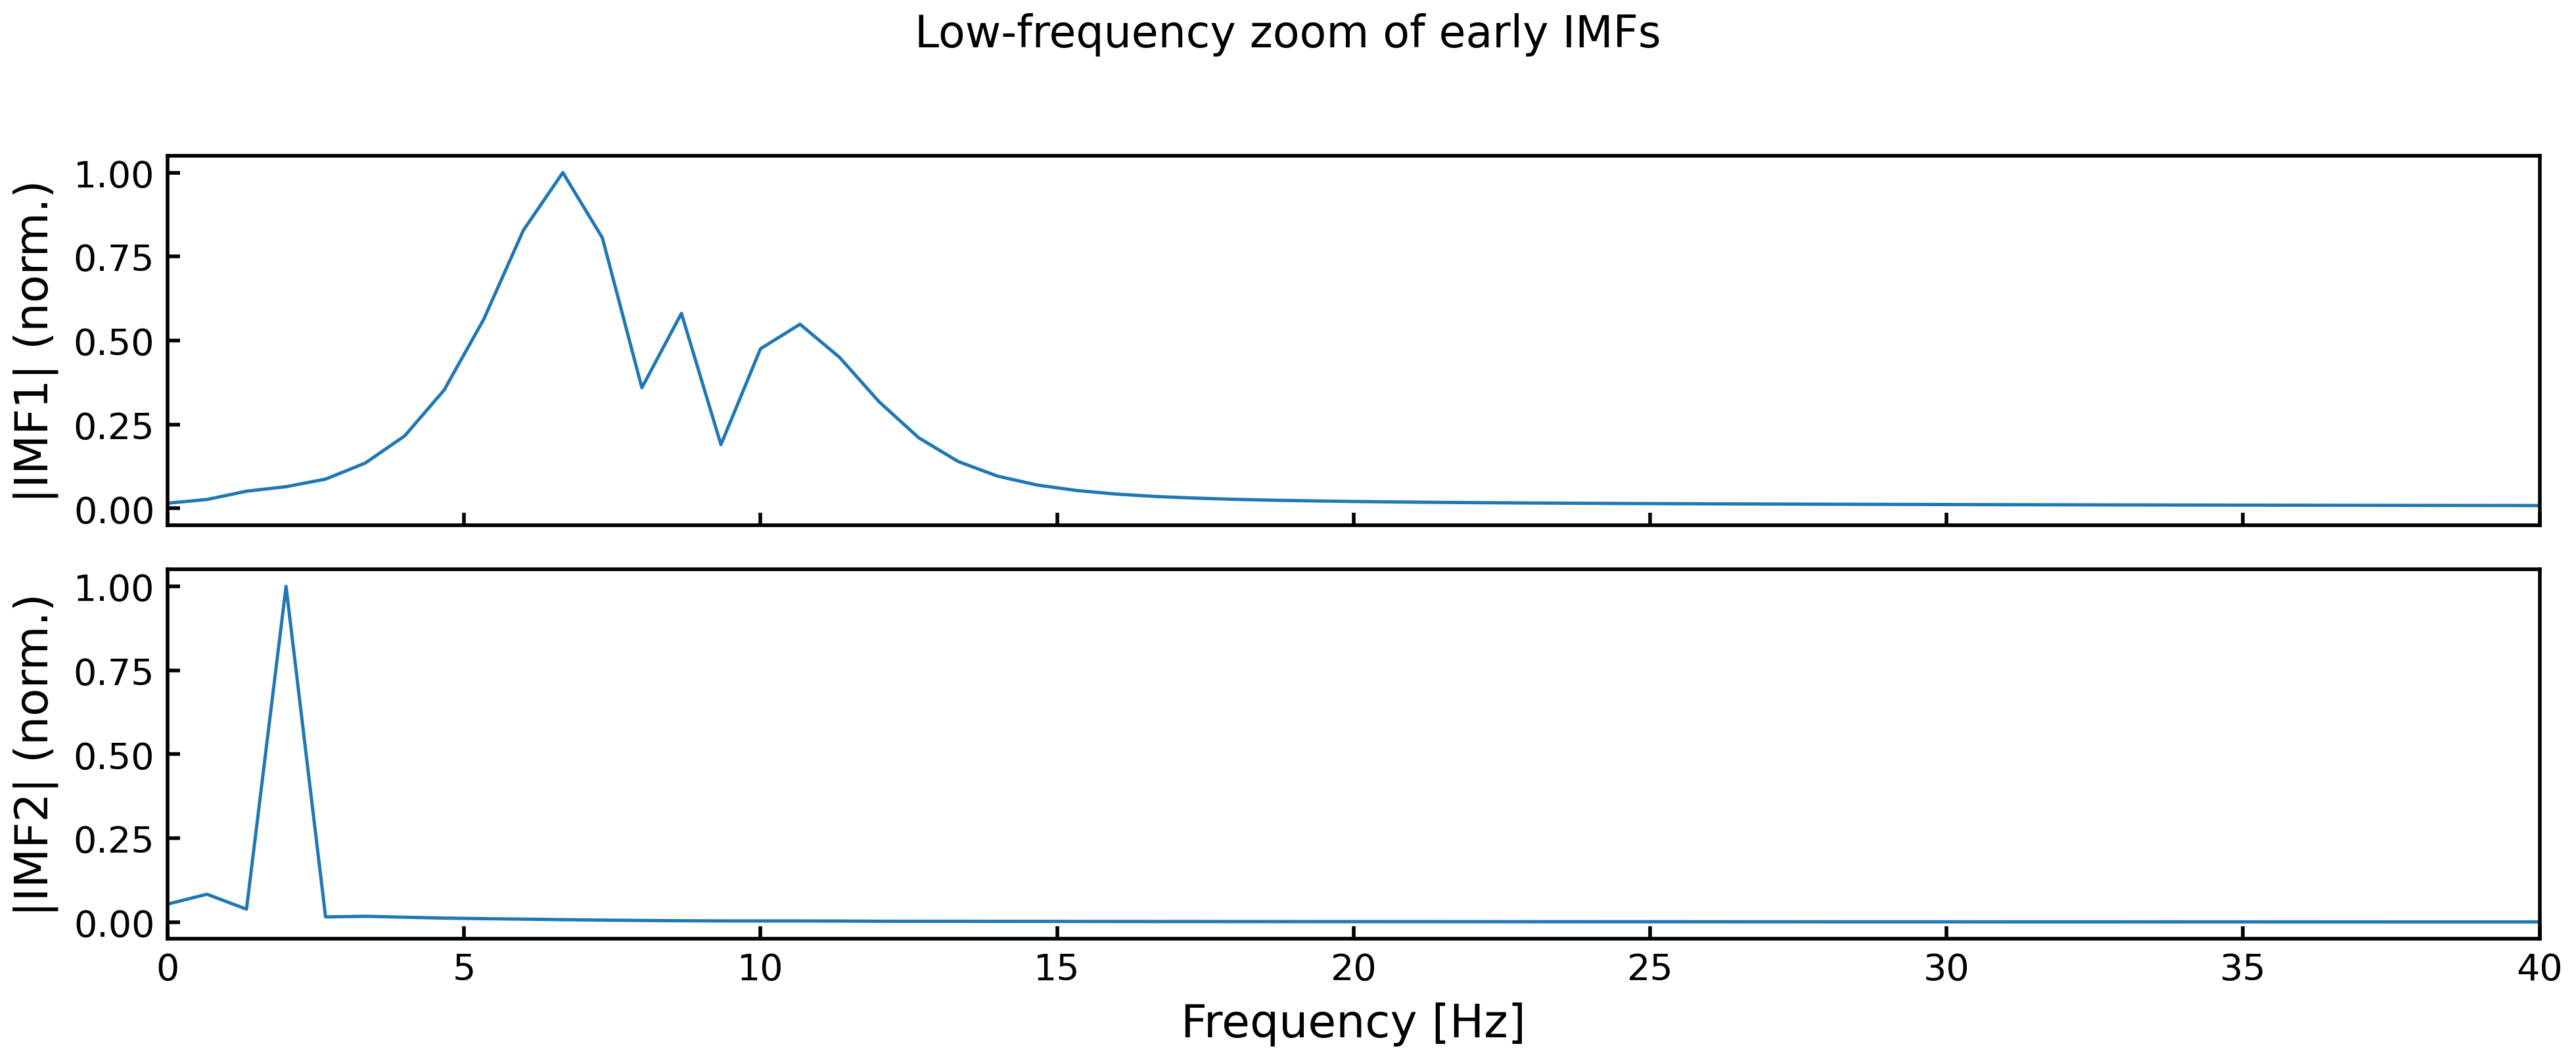

In [5]:
plot_IMFs_amplitude_spectra(imfs, norm=True)
plt.show()

# Zoomed Fourier view of the first two IMFs (paper-style frequency check)
freqs = np.fft.rfftfreq(N, d=1.0 / fs)
fig, axes = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
for i, ax in enumerate(axes):
    spec = np.abs(np.fft.rfft(imfs[i]))
    ax.plot(freqs, spec / (spec.max() + 1e-12), lw=0.9)
    ax.set_ylabel(f"|IMF{i+1}| (norm.)")
    ax.set_xlim(0, 40)
axes[-1].set_xlabel("Frequency [Hz]")
fig.suptitle("Low-frequency zoom of early IMFs", y=1.02)
fig.tight_layout()
plt.show()

## 7. Soft sifting cost $f(j)$

For each IMF, the SSSC stores $f(j)$ over sifting iterations. The chosen
iteration is the minimizer (vertical dashed line).


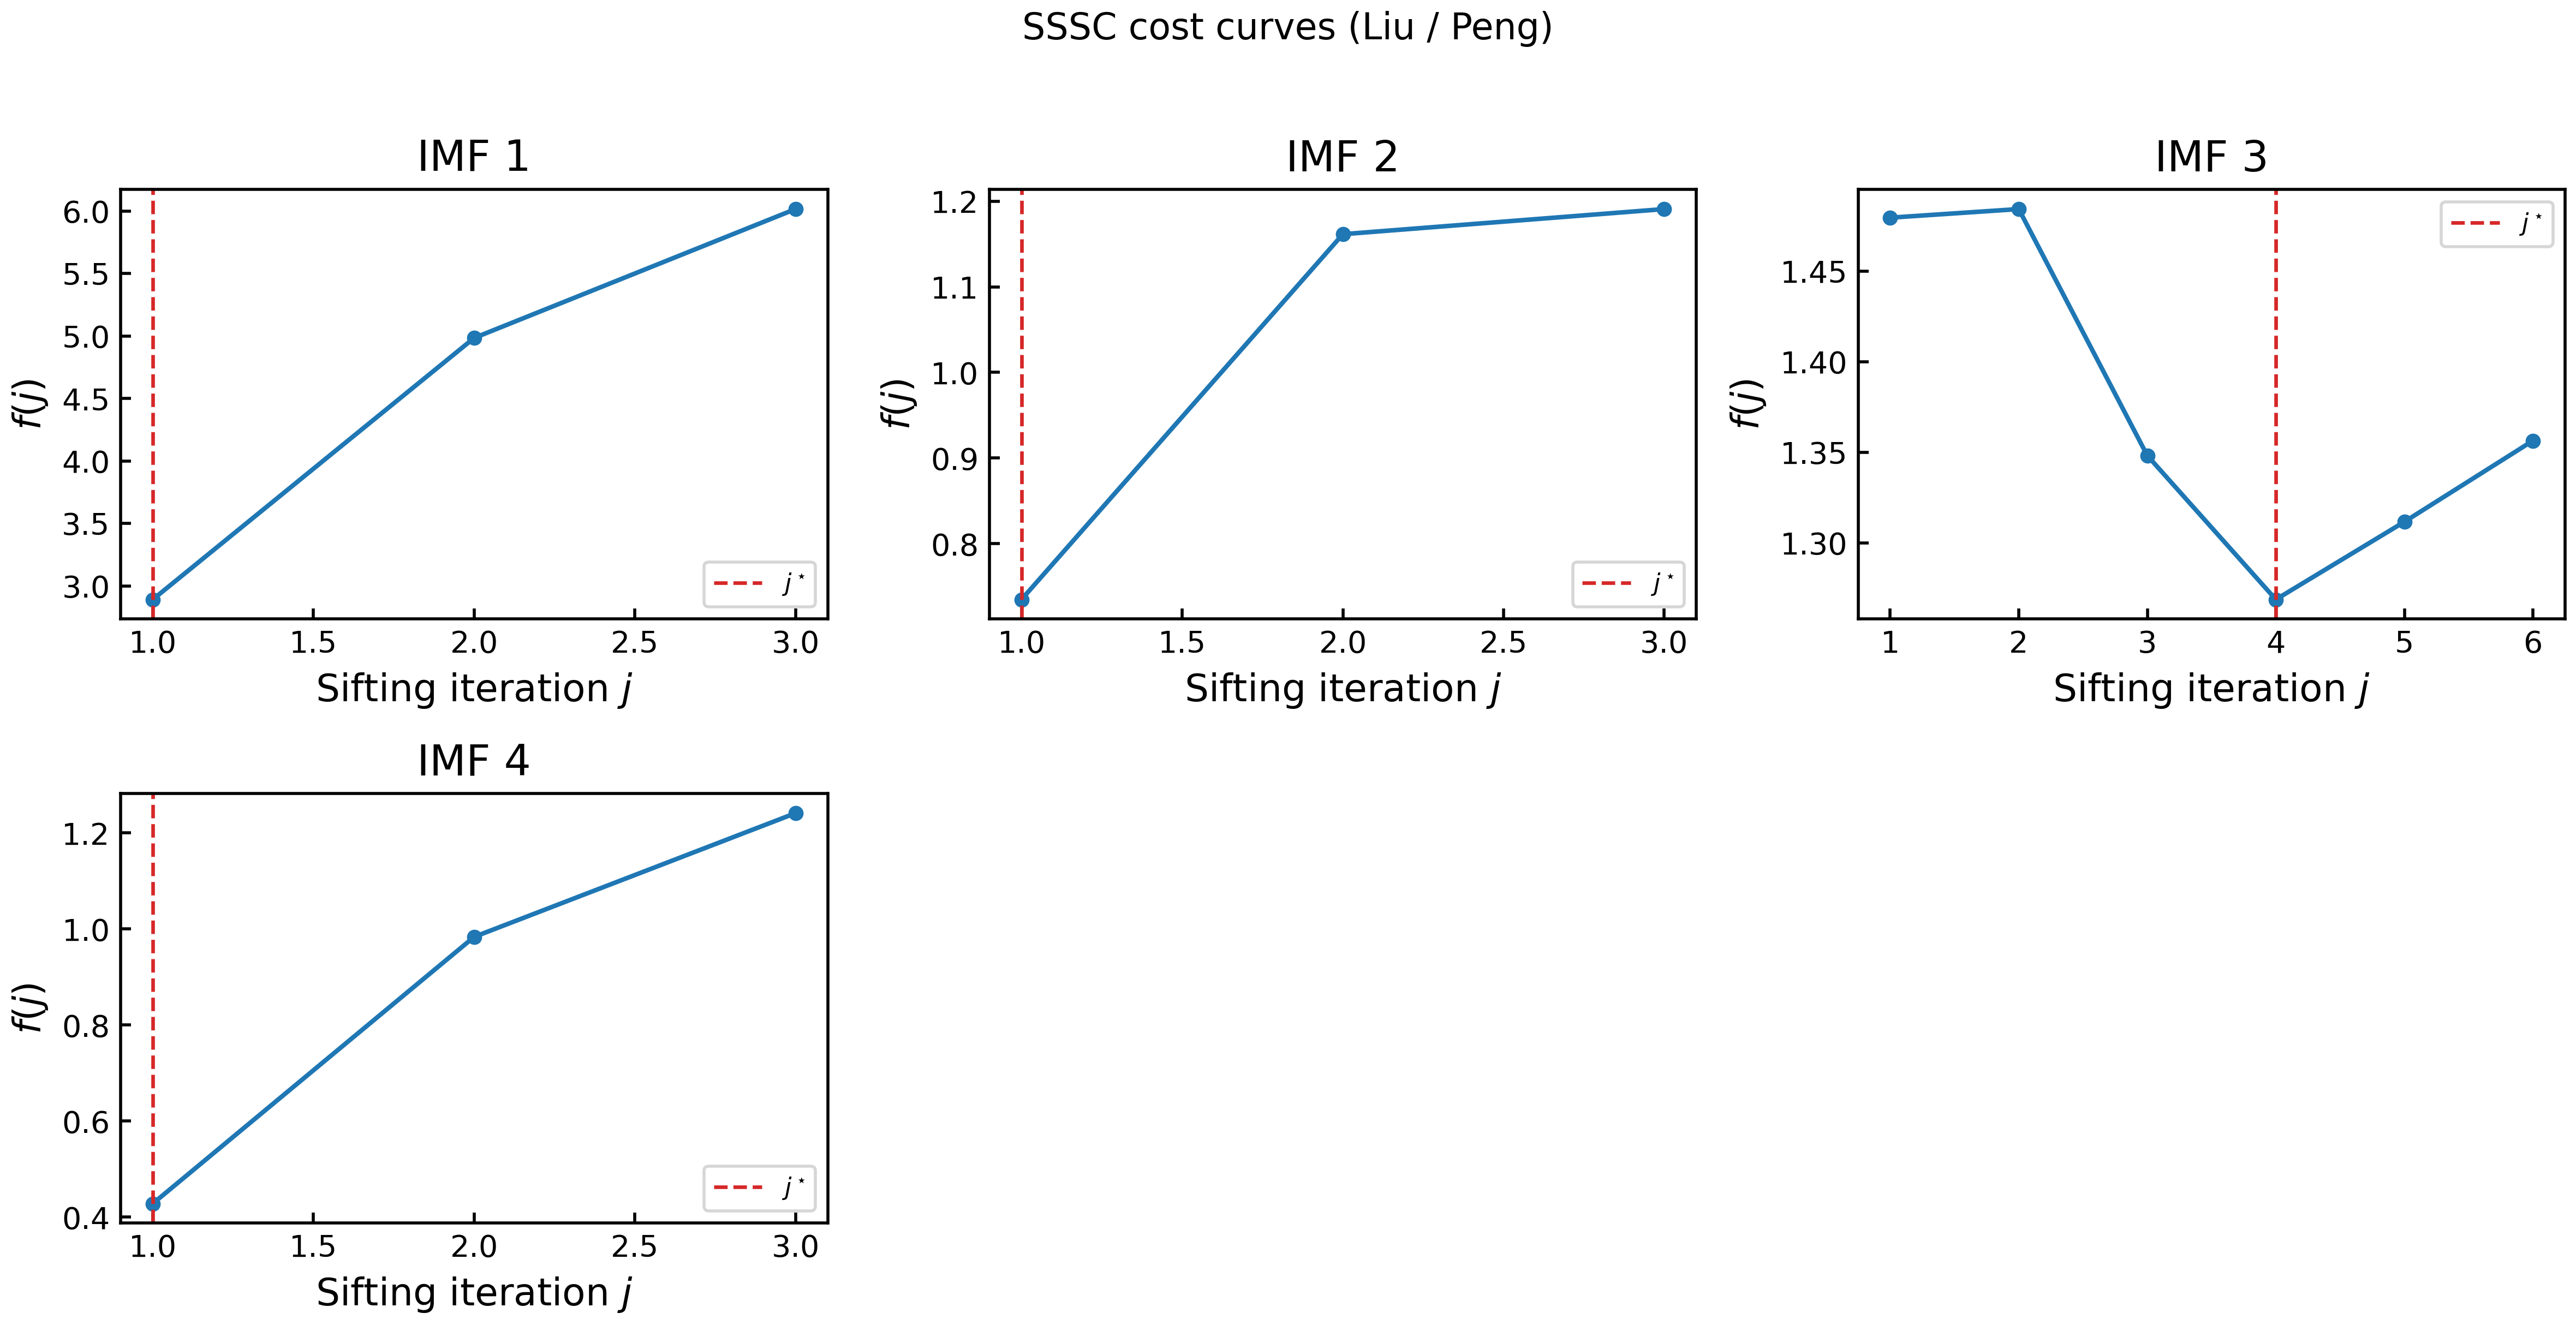

In [6]:
n_imf = len(iter_num)
ncols = min(n_imf, 3)
nrows = int(np.ceil(n_imf / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), squeeze=False)

for i in range(n_imf):
    ax = axes[i // ncols][i % ncols]
    j_star = int(iter_num[i])
    fv = fvs[i, :j_star]
    # show recorded values up to stop (nonzeros / filled prefix)
    filled = fvs[i]
    last = int(np.max(np.where(filled != 0)[0])) + 1 if np.any(filled != 0) else j_star
    last = max(last, j_star)
    ax.plot(np.arange(1, last + 1), filled[:last], "o-", ms=4)
    ax.axvline(j_star, color="C3", ls="--", lw=1.2, label=r"$j^\star$")
    ax.set_title(f"IMF {i + 1}")
    ax.set_xlabel("Sifting iteration $j$")
    ax.set_ylabel(r"$f(j)$")
    ax.legend(loc="best", fontsize=8)

for j in range(n_imf, nrows * ncols):
    axes[j // ncols][j % ncols].axis("off")

fig.suptitle("SSSC cost curves (Liu / Peng)", y=1.02)
fig.tight_layout()
plt.show()

## 8. Optional: REMD vs classical EMD

A quick side-by-side on a shorter segment.  Because REMD selects $k^\star$ from
$f(j)$ rather than a hard SD cutoff, the first IMF on multicomponent AM-FM
mixtures is often cleaner (fewer leftover low-frequency beats from undersifting,
less breakup from oversifting).  See Section 2.1-2.5 for the corresponding
paper argument.


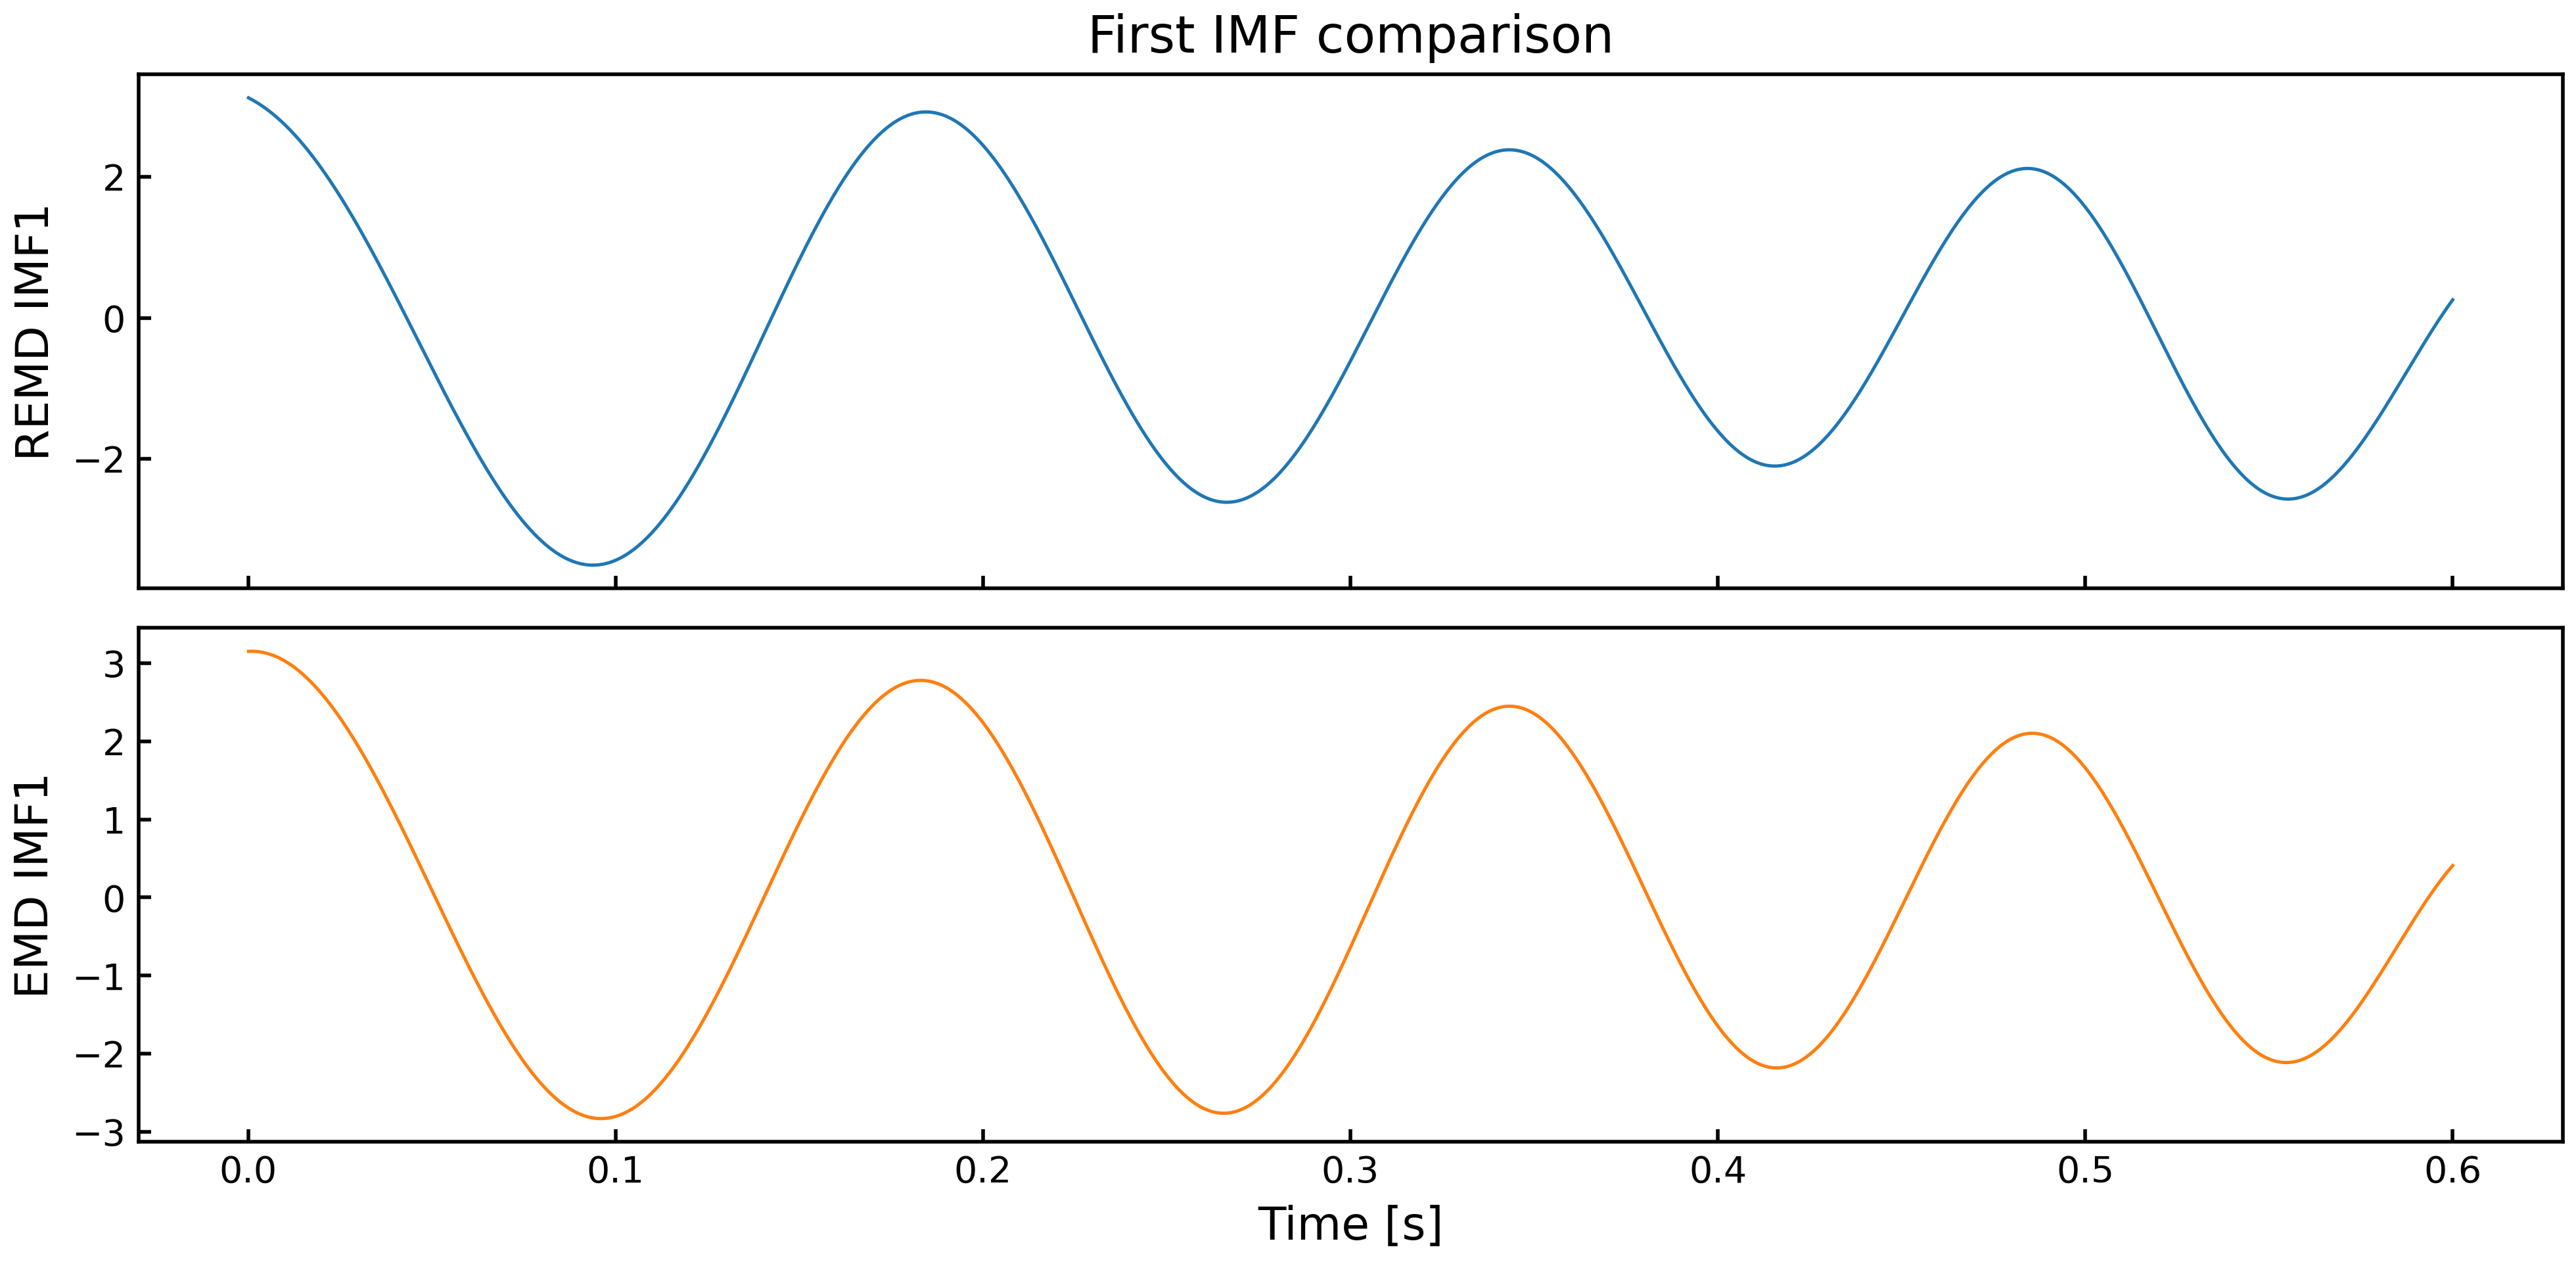

REMD rows: 3 | EMD rows: 2


In [7]:
N2 = 6000
t2 = t[:N2]
x2 = x[:N2]

imf_remd = REMD(max_imfs=4, max_iter=30)(x2)
imf_emd = EMD(max_imfs=4)(x2)

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(t2, imf_remd[0], lw=0.9)
axes[0].set_ylabel("REMD IMF1")
axes[0].set_title("First IMF comparison")
axes[1].plot(t2, imf_emd[0], lw=0.9, color="C1")
axes[1].set_ylabel("EMD IMF1")
axes[1].set_xlabel("Time [s]")
fig.tight_layout()
plt.show()

print("REMD rows:", imf_remd.shape[0], "| EMD rows:", imf_emd.shape[0])